
---------------------------------------------------------
 RESULTADOS PARA: USA
---------------------------------------------------------
corr(CA/PIB, ciclo) = -0.232 [R2]
corr(TB/PIB, ciclo) = -0.212 [R3]
corr(I/PIB, ciclo) = +0.530 [R4]
sigma(I) / sigma(C) = +0.796 [R5]
corr(S/PIB, I/PIB) = +0.687 [R6]

---------------------------------------------------------
 RESULTADOS PARA: DEU
---------------------------------------------------------
corr(CA/PIB, ciclo) = -0.022 [R2]
corr(TB/PIB, ciclo) = -0.008 [R3]
corr(I/PIB, ciclo) = +0.270 [R4]
sigma(I) / sigma(C) = +1.637 [R5]
corr(S/PIB, I/PIB) = -0.265 [R6]

---------------------------------------------------------
 RESULTADOS PARA: CHN
---------------------------------------------------------
corr(CA/PIB, ciclo) = +0.082 [R2]
corr(TB/PIB, ciclo) = +0.104 [R3]
corr(I/PIB, ciclo) = +0.123 [R4]
sigma(I) / sigma(C) = +0.916 [R5]
corr(S/PIB, I/PIB) = +0.838 [R6]

---------------------------------------------------------
 RESULTADOS PARA: PE

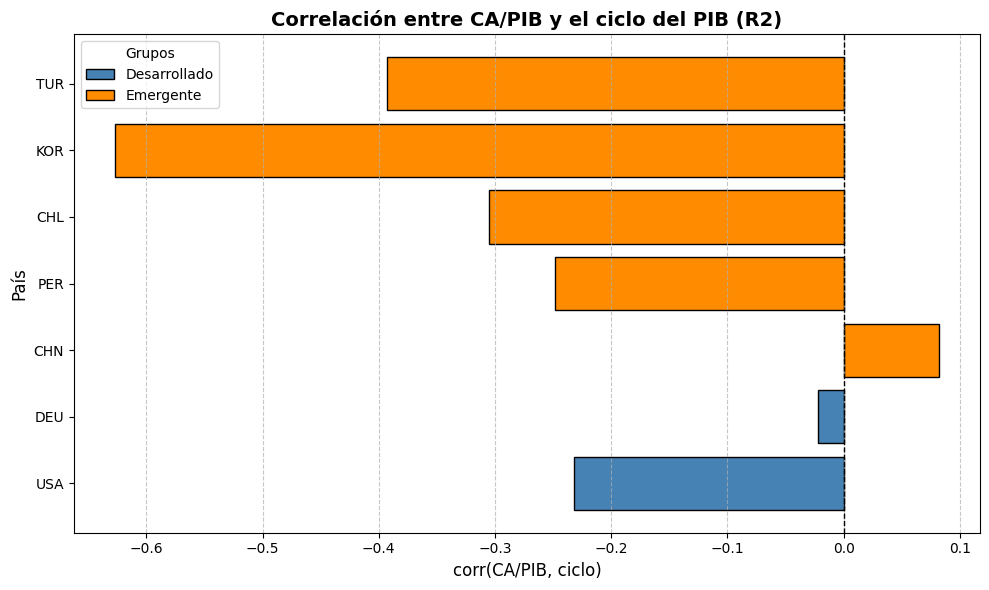

In [1]:

!pip install numpy pandas statsmodels matplotlib wbgapi -q

# -- Librerias -------------------------------------------------------
import wbgapi as wb
import pandas as pd
import numpy as np
from statsmodels.tsa.filters.hp_filter import hpfilter
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from IPython.display import display
from scipy.optimize import differential_evolution
import warnings


# BLOQUE A

# PREGUNTA 22

# DICCIONARIOS -----------------------------------------------------------------
indicators = {
    'NY.GDP.MKTP.KD': 'gdp_real',    # PIB real
    'BN.CAB.XOKA.GD.ZS': 'ca_gdp',   # Cuenta corriente / PIB
    'NE.RSB.GNFS.ZS': 'tb_gdp',      # Balanza comercial / PIB
    'NE.GDI.TOTL.ZS': 'inv_gdp',     # Inversion bruta / PIB
    'NY.GNS.ICTR.ZS': 'sav_gdp',     # Ahorro bruto / PIB
    'NE.CON.TOTL.ZS': 'cons_gdp',    # Consumo total / PIB
}

paises = ['USA', 'DEU', 'CHN', 'PER', 'CHL', 'KOR', 'TUR']

clasificacion = {
    'USA': 'Desarrollado', 'DEU': 'Desarrollado',
    'CHN': 'Emergente', 'PER': 'Emergente', 'CHL': 'Emergente',
    'KOR': 'Emergente', 'TUR': 'Emergente'
}

colores_grupo = {'Desarrollado': 'steelblue', 'Emergente': 'darkorange'}

#Diccionario donde se almacenaran los datos de R2 de todos los paises
resultados_ca = {}

# CODIGO -----------------------------------------------------------------

#Bucle para imprimir R2 - R6 de todos los paises del Diccionario

for pais in paises:
    print(f"\n---------------------------------------------------------")
    print(f" RESULTADOS PARA: {pais}")
    print(f"---------------------------------------------------------")

    # 1. Descarga de datos
    raw = wb.data.DataFrame(
        list(indicators.keys()),
        economy = pais,
        time = range(1990, 2024)
    )

    # 2. Transponer y limpiar
    df = raw.T
    df.columns = [indicators[c] for c in raw.index]
    df.index = [int(str(i).replace('YR', '')) for i in df.index]
    df = df.sort_index().astype(float)

    # 3. Filtro HP
    df_clean = df['gdp_real'].dropna()
    cycle, trend = hpfilter(x=np.log(df_clean), lamb=6.25)
    df['gdp_cycle'] = cycle.reindex(df.index)

    # 4. Estadisticos ciclicos
    corr_CA = df['gdp_cycle'].corr(df['ca_gdp'])
    corr_TB = df['gdp_cycle'].corr(df['tb_gdp'])
    corr_I = df['gdp_cycle'].corr(df['inv_gdp'])
    vol_ratio = df['inv_gdp'].std() / df['cons_gdp'].std()
    corr_SI = df['sav_gdp'].corr(df['inv_gdp'])

    # Almacenar el R2 del pais en el diccionario general
    resultados_ca[pais] = corr_CA

    # 5. Mostrar los resultados
    print(f"corr(CA/PIB, ciclo) = {corr_CA:+.3f} [R2]")
    print(f"corr(TB/PIB, ciclo) = {corr_TB:+.3f} [R3]")
    print(f"corr(I/PIB, ciclo) = {corr_I:+.3f} [R4]")
    print(f"sigma(I) / sigma(C) = {vol_ratio:+.3f} [R5]")
    print(f"corr(S/PIB, I/PIB) = {corr_SI:+.3f} [R6]")

# GRAFICO -----------------------------------------------------------------

# Obtenemos la lista de los datos de R2 de los paises
paises_grafico = list(resultados_ca.keys())
valores_ca = list(resultados_ca.values())

# Asignamos el color a cada pais
colores_barras = [colores_grupo[clasificacion[p]] for p in paises_grafico]

# Configuracion del grafico

plt.figure(figsize=(10, 6))
plt.barh(paises_grafico, valores_ca, color=colores_barras, edgecolor='black')
plt.axvline(0, color='black', linewidth=1, linestyle='--')

# Titulos y etiquetas
plt.title('Correlación entre CA/PIB y el ciclo del PIB (R2)', fontsize=14, fontweight='bold')
plt.xlabel('corr(CA/PIB, ciclo)', fontsize=12)
plt.ylabel('País', fontsize=12)

# Leyenda
elementos_leyenda = [
    Patch(facecolor='steelblue', edgecolor='black', label='Desarrollado'),
    Patch(facecolor='darkorange', edgecolor='black', label='Emergente')
]
plt.legend(handles=elementos_leyenda, title='Grupos')

# Mostrar el gráfico
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
print()
print()
plt.show()


In [2]:
# PREGUNTA 23

"""
a) ¿Para cuántos países se cumple R2 (CA contracíclica)?  ¿Es la CA más contracíclica en emergentes que en desarrollados, como predice R7? ¿Qué dice este patrón sobre la relevancia relativa del canal de inversión frente al de suavización del consumo en cada grupo?
"""

"""
Se observa graficamente que se cumple la prediccion de R2 para 6 de los 7 paises. Siendo China el unico pais cuya cuenta corriente es prociclica.

Adicionalmente, también se observa graficamente que el promedio del valor absoluto de los coeficientes de R2 en los paises emergentes son mayores que en los paises desarrollados, por lo tanto si se cumple R7.

Este patrón nos indica cómo llegan a actuar las 2 categorias de paises (desarrollado y emergente) ante shocks productivos. Nos demuestra que, por ejemplo, ante shocks positivos de productividad, los paises emergentes, aumentan su inversión doméstica rapidamente superando al ahorro interno (dominando el canal de inversión). Esto los obliga a financiarse con ahorro externo (aumento de deuda) generando así ese déficit de Cuenta Corriente. Por otro lado, los paises desarrollados, ante el mismo shock, no generan los mismos movimientos en la Cuenta Corriente, siendo más atenuados (dominando el canal de suavización). Siendo que internamente se prefiere suavizar el consumo y absorver gran parte del shock a travez de sus ahorros.

"""


"""
b) ¿Se cumple R6 para todos los países? Si algún país muestra una correlación S–I particularmente baja, ¿qué podría indicar sobre el grado de integración financiera internacional
de ese país?
"""

"""

Se puede observar en los resultados que el R6 no se cumple en todos los paises, específicamente en Alemania, cuyo valor es -0.265. Y en Chile, cuya correlacion, a pesar de ser positiva, es muy baja (0.124) para considerarla significante.

Para el caso particular de Alemania, que su correlación sea negativa nos indica que a pesar que su ahorro interno suba, su inversión interna no sube. Esto se debe a que, al estar muy integrados internacionalmente, invierten sus ahorros en otros países con mayores retornos, el cual no es necesariamente Alemania, sino otros paises con mayores retornos. Análogamente, los otros paises tienen más ligado su ahorro a su inversión interna, lo cual quiere decir que, en vez de ahorrar internacionalmente, ahorran e invierten nacionalmente.

"""

"""

(c) ¿En qué países falla R5 (σ(I)/σ(C) > 1)? ¿Qué tipo de economías exhiben σ(C) > σ(I)
y qué sugiere esto sobre la naturaleza de los shocks que enfrentan?

"""

"""

La predicción de R5 falla en 5 de los 7 paises (Estados Unidos, China, Perú, Chile y Turquía). Solo Alemania y Corea del Sur cumplen con R5. Esto sugiere que los shocks que reciben son mayormente permanentes. Esto dado que ante un aumento del nivel de ingreso permanente, los agentes ajustan su consumo agresivamente, volviendo al consumo bastante volatil, incluso más que la inversión.

"""

# Dos países cuyos resultados no coincidan con las predicciones teóricas

"""

Primero voy a hablar de China, como se vio en la pregunta a. China es un país emergente, el cual tenia una Cuenta Corriente prociclica (falla en R2). Esto nos indica que cuando pasa por un "boom", en vez de aumentar su deuda para aprovecharlo (disminución de la Cuenta Corriente), aumenta su Cuenta Corriente. Citando la Parte IV del Problem Set y especificamente a Bernanke (2005), esta contradicción a la predicción se debe a que economías emergentes como China acumularon masivamente reservas internacionales tras las crisis asiatica de 1997 - 1998. Esto generó lo que Bernake llamó un "exceso global de ahorro", ocasionado que China actue como el prestamista del mundo, sin importar la fase del ciclo economico en la que se encuentre.

Luego voy a hablar de Alemania, como se vio en la pregunta b. Alemania es un país en el cual el ahorro y la inversion interna no se mueven en la misma dirección (falla en R6). Esto se debe a su pertenencia a una unión monetaria sin poder influir directamente en el tipo de cambio. El modelo intertemporal que se desarollo en la parte I y II asume una economía abierta pequeña e independiente (siendo esta última el supuesto no cumplida en el caso Alemán). No obstante, Alemania, al compartir al Euro con el resto de la Union Europea, ante un shock positivo nacional, el Euro no se aprecia, lo cual no frena sus expotaciones y por ende, no ajusta su Cuenta Corriente. Además, al estar en un mercado financiero unificado bajo la misma moneda, Alemania actua como un gran acreedor, destinando su gran ahorro interno a la inversion extranjera en vez de a la local como los demás paises en la lista.

"""

'\n\nPrimero voy a hablar de China, como se vio en la pregunta a. China es un país emergente, el cual tenia una Cuenta Corriente prociclica (falla en R2). Esto nos indica que cuando pasa por un "boom", en vez de aumentar su deuda para aprovecharlo (disminución de la Cuenta Corriente), aumenta su Cuenta Corriente. Citando la Parte IV del Problem Set y especificamente a Bernanke (2005), esta contradicción a la predicción se debe a que economías emergentes como China acumularon masivamente reservas internacionales tras las crisis asiatica de 1997 - 1998. Esto generó lo que Bernake llamó un "exceso global de ahorro", ocasionado que China actue como el prestamista del mundo, sin importar la fase del ciclo economico en la que se encuentre.\n\nLuego voy a hablar de Alemania, como se vio en la pregunta b. Alemania es un país en el cual el ahorro y la inversion interna no se mueven en la misma dirección (falla en R6). Esto se debe a su pertenencia a una unión monetaria sin poder influir directa